In [2]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fontsize = 14
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": fontsize,
    #'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents}',
    'figure.dpi': 200
})

In [4]:
from typing import Dict, Tuple, Optional

def get_last_file(path : Path) -> Path | None:
    files = []
    pattern = os.path.join(path, "TR_IRGNM_*.pkl")
    files += glob.glob(pattern)
    pattern = os.path.join(path, "FOM_IRGNM_*.pkl")
    files += glob.glob(pattern)

    indices = []
    for f in files:
        match = re.search(r'_*(?:TR|FOM)_IRGNM_(\d+)\.pkl$', f)
        if match:
            idx = int(match.group(1))
            indices.append((idx, f))
    
    if indices:
        _, max_file = max(indices, key=lambda x: x[0])
        
        return Path(max_file).name
    else:
        print("No matching files found.")

    return None

def filter_and_reorder(d: Dict, pattern: str = r'.*FOM.*') -> Tuple[Dict, Optional[str]]:
    regex = re.compile(pattern)
    matching = [k for k in d if regex.search(k)]
    non_matching = [k for k in d if k not in matching]

    # Sort keys alphabetically within each group
    non_matching_sorted = sorted(non_matching)
    matching_sorted = sorted(matching)

    # Build the reordered dict: alphabetically sorted non-matching first, then matching ones
    reordered = {k: d[k] for k in non_matching_sorted}
    reordered.update({k: d[k] for k in matching_sorted})

    # Return reordered dict and the single matching key (if exactly one match)
    if len(matching_sorted) == 1:
        return reordered, matching_sorted[0]
    else:
        return reordered, None

In [21]:
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
WORK_DIR = Path('/home/dealii/workdir/experiments')
#äWORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
#SAVE_PATH = Path('/home/benedikt/Dokumente/Paper/linear_elasticity/figures/experiments')


SAVE_PATH = Path('/home/dealii/workdir/figs')

subset = 'new_baseline'
obs_op = 'sensors'
data_dir_path = WORK_DIR / 'show_mario' / 'new_baseline_'
#data_dir_path = WORK_DIR / 'greater_defect'

experiment_names = []
pattern = re.compile(rf'^{subset}_.*_{obs_op}.*')

experiment_names += [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

# pattern = re.compile(rf'^.*FOM.*_{obs_op}.*')
# experiment_names += [
#     d.name for d in data_dir_path.iterdir()
#     if d.is_dir() and pattern.match(d.name)
# ]

#experiment_names = experiment_names[:-1]
#experiment_names.append('baseline_FOM_sensors')
#experiment_names.append('baseline_FOM_sensors')

data_paths = [ data_dir_path / experiment_name for experiment_name in experiment_names]
file_names = [get_last_file(data_path) for data_path in data_paths]

#print(data_paths)
#print(file_names)

setup = None
data = {}
optimizer_parameters = {}

for (data_path, file_name) in zip(data_paths, file_names):            

    try:
        with open(data_path / file_name, 'rb') as file:
            data_ = load(file)
        data[str(data_path.name)] = data_
    except TypeError:
        print(f"Can not find dumps for {data_path}")
    except:
        print(f"Can not open {data_path / file_name}")

    if not setup:
        with open(data_path / 'setup.pkl', 'rb') as file:
            setup = load(file)

    
    optimizer_parameter_path = data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
        
    optimizer_parameters[str(data_path.name)] = optimizer_parameter

data, FOM_key = filter_and_reorder(data, pattern=r'.*FOM.*')
#assert FOM_key

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

print(data.keys())


dict_keys(['new_baseline_TR_sensors', 'new_baseline_TR_sensors_krylov', 'new_baseline_TR_sensors_time_step', 'new_baseline_TR_sensors_time_step_full', 'new_baseline_FOM_sensors'])


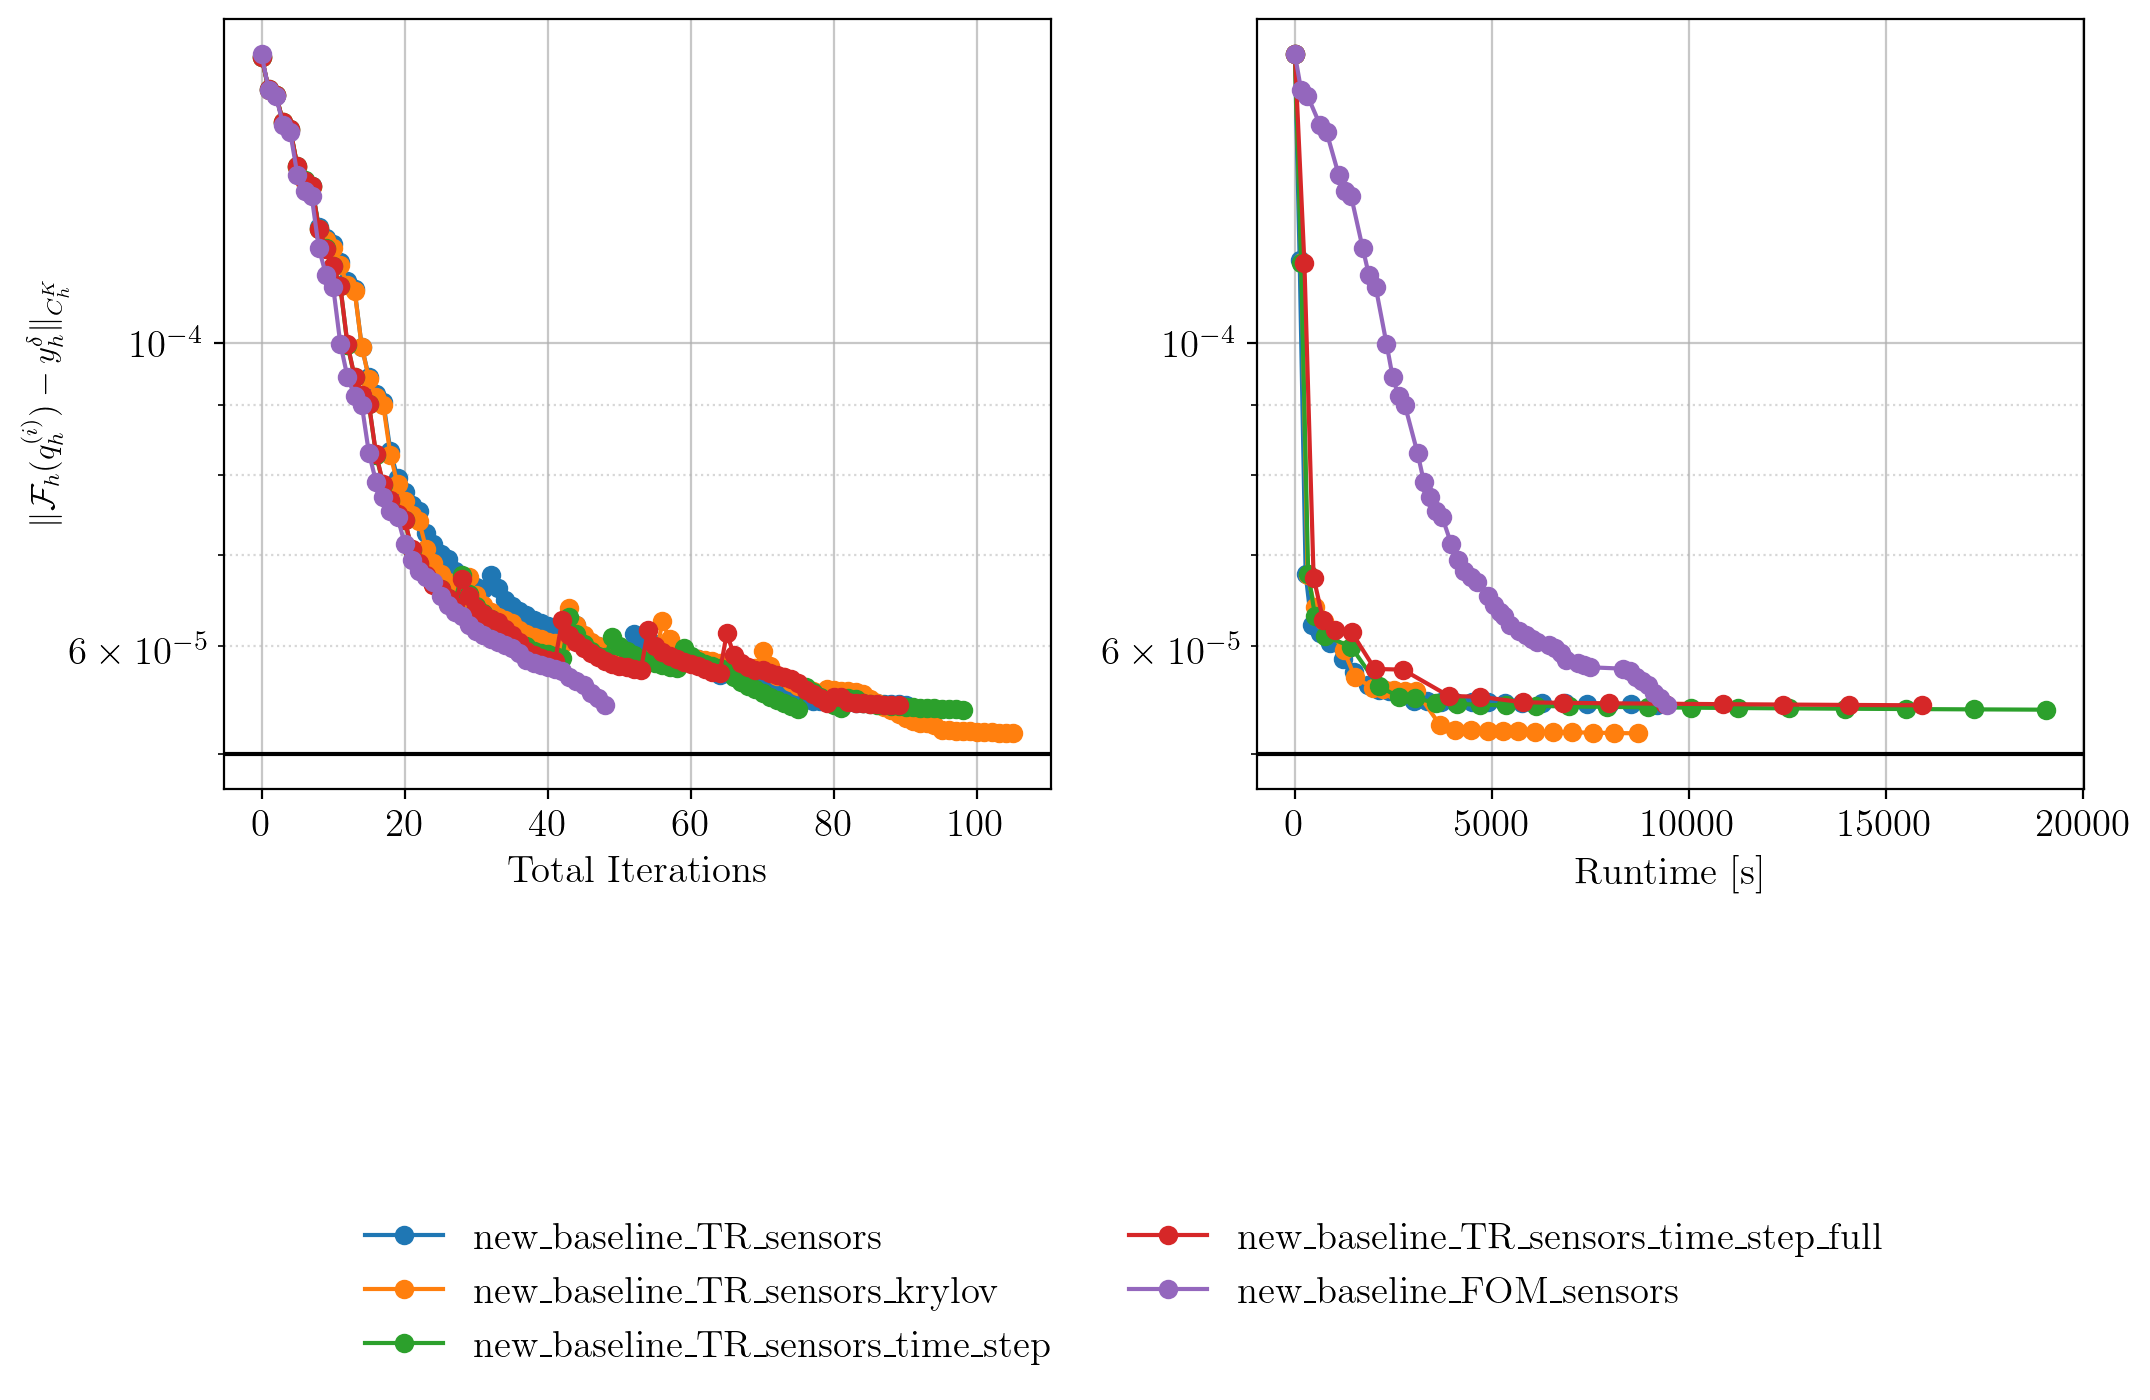

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# --- Figure + layout ---
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
gs.update(wspace=0.25)

# --- Common threshold params ---
try:
    tau = optimizer_parameters[FOM_key]['tau']
except Exception:
    tau = list(optimizer_parameters.values())[-1]['tau']
delta = setup['noise_level']
#delta = noise_level
threshold = np.sqrt(2 * (0.5 * tau**2 * delta**2))  # sqrt(2 * J)
#threshold = None

# =========================
# Left: J vs total iterations
# =========================
ax_iter = fig.add_subplot(gs[0])

for experiment_name, experiment_data in dict(list(data.items())[:]).items():
    Js = []
    try:
        inner_loop_statistics = experiment_data.get('inner_loop_statistics', None)
        if inner_loop_statistics:
            for inner_loop_statistic in inner_loop_statistics:
                Js += inner_loop_statistic['J']
        else:
            Js += experiment_data['J']
    except Exception:
        Js += experiment_data['J']

    Js = np.sqrt(2 * np.array(Js))
    ax_iter.plot(Js, marker='o', label=experiment_name)

if threshold:
    ax_iter.axhline(threshold, color='black')
ax_iter.set_xlabel('Total Iterations')
ax_iter.set_yscale('log')
ax_iter.grid(True, which='major', linestyle='-', alpha=0.7)
ax_iter.grid(True, which='minor', linestyle=':', alpha=0.5)

# =========================
# Right: J vs runtime (s)
# =========================
ax_time = fig.add_subplot(gs[1])

for experiment_name, experiment_data in dict(list(data.items())[:]).items():
    Js = np.sqrt(2 * np.array(experiment_data['J']))    
    try:
        times = np.array([0])
        times = np.append(times, experiment_data['total_runtime'])
        ax_time.plot(times, Js, marker='o', label=experiment_name)
    except Exception:
        times = np.array([0])
        times = np.append(times, experiment_data['time_steps'])
        ax_time.plot(times, Js, marker='o', label=experiment_name)
        
if threshold:
    ax_time.axhline(threshold, color='black')
ax_time.set_xlabel('Runtime [s]')
ax_time.set_yscale('log')
ax_time.grid(True, which='major', linestyle='-', alpha=0.7)
ax_time.grid(True, which='minor', linestyle=':', alpha=0.5)

# =========================
# Shared ylabel and joint legend
# =========================
fig.text(0.04, 0.5, r'$\|\mathcal{F}_h(q_h^{(i)}) - y_h^{\delta}\|_{C^K_h}$',
         va='center', rotation='vertical', fontsize=12)



# Joint legend below both subplots (with padding to avoid overlap)
handles, labels = ax_iter.get_legend_handles_labels()
#custom_labels = ['TR-IRGNM-I','TR-IRGNM-II','TR-IRGNM-III','TR-IRGNM-IV','TR-IRGNM-V', 'FOM-IRGNM']
#fig.legend(handles, custom_labels, loc='lower center', ncol=3, frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, -0.20))

fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, -0.50))

# Adjust layout: reserve space for legend and avoid overlap
plt.tight_layout(rect=[0.05, 0.18, 1, 1])  # extra bottom margin

#plt.show()
#fig.savefig(SAVE_PATH / Path(f'{subset}_{obs_op}_decay_plots.pdf'), bbox_inches="tight")


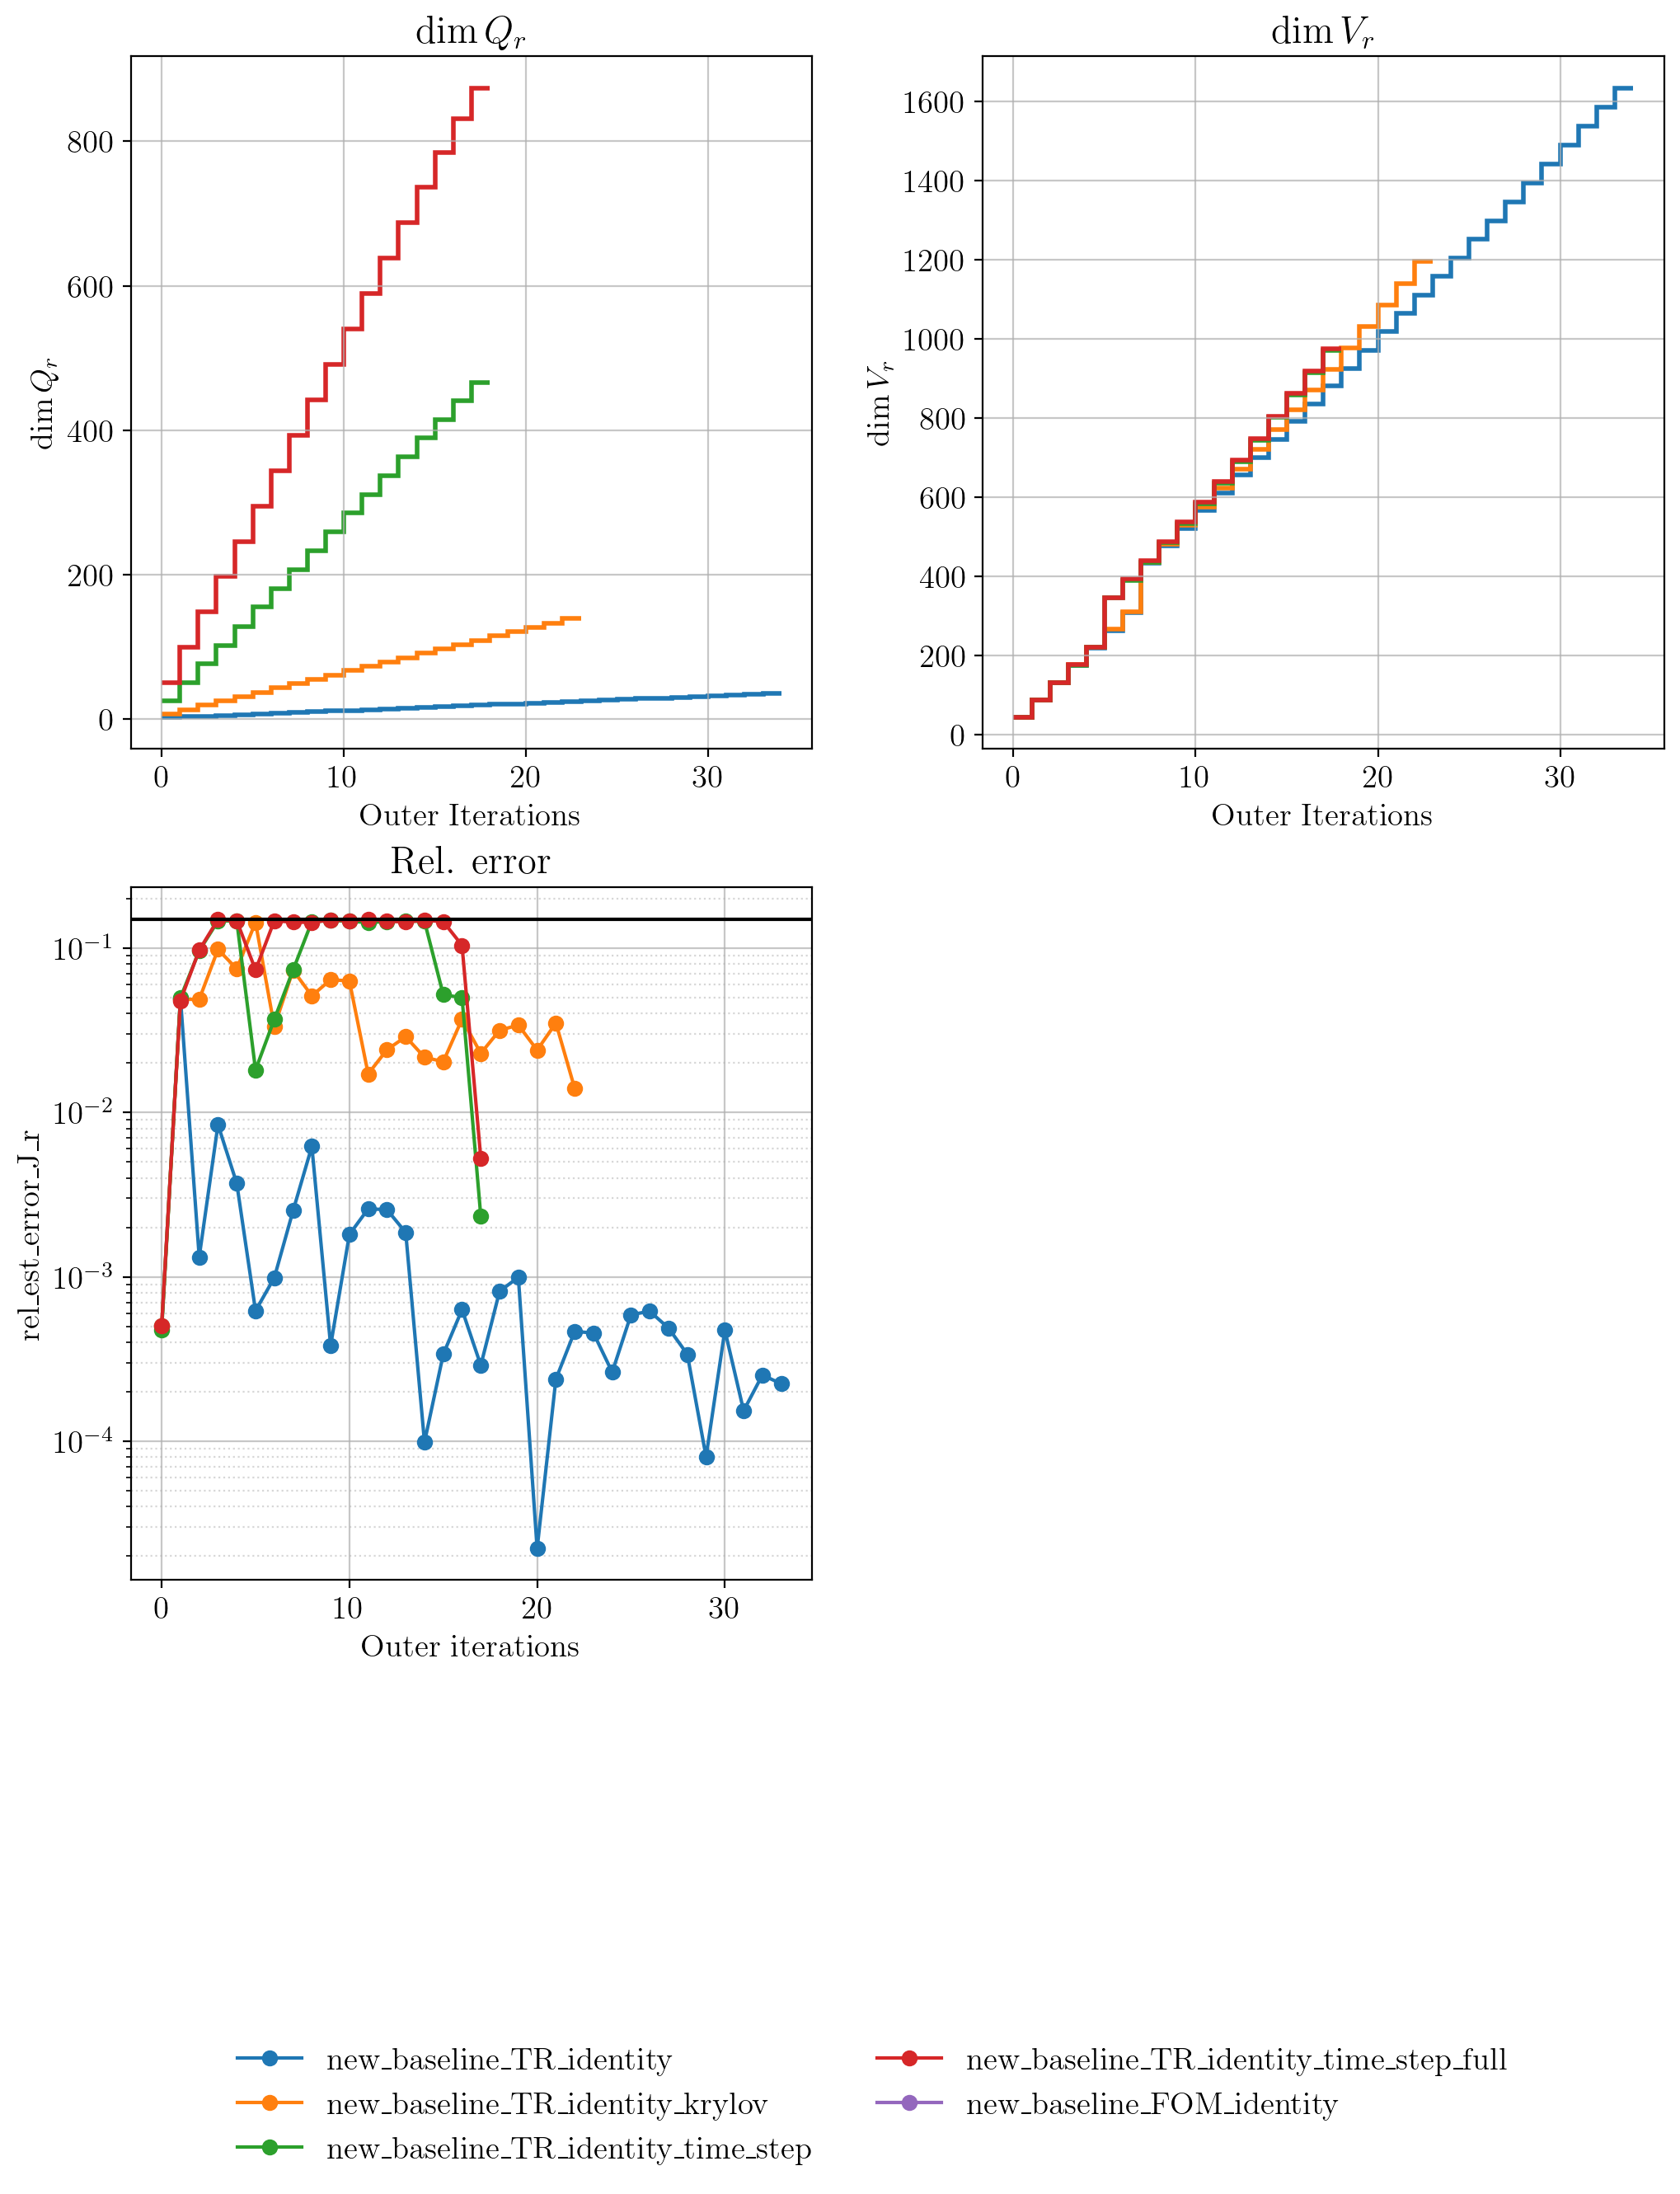

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# --- Figure + layout ---
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1])
gs.update(wspace=0.25)

# =========================
# Left
# =========================
ax = fig.add_subplot(gs[0])

for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    dim_Q_r = experiment_data['dim_Q_r']
    ax.stairs(dim_Q_r, label=experiment_name, baseline=None, linewidth=2)

ax.set_title(r'$\dim Q_r$')
ax.set_ylabel(r'$\dim Q_r$')
ax.set_xlabel('Outer Iterations')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

# =========================
# Middel
# =========================
ax = fig.add_subplot(gs[1])

for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    dim_V_r = experiment_data['dim_V_r']
    ax.stairs(dim_V_r, label=experiment_name, baseline=None, linewidth=2)

ax.set_title(r'$\dim V_r$')
ax.set_ylabel(r'$\dim V_r$')
ax.set_xlabel('Outer Iterations')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.5)

# =========================
# Right
# =========================
ax = fig.add_subplot(gs[2])

for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    ax.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        

ax.axhline(0.15, color='black')

ax.set_title(r'Rel. error')
ax.set_ylabel('rel_est_error_J_r')
ax.set_xlabel('Outer iterations')
ax.set_yscale('log')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.5)
# =========================
# Shared ylabel and joint legend
# =========================


# Joint legend below both subplots (with padding to avoid overlap)
handles, labels = ax_iter.get_legend_handles_labels()
#custom_labels = ['TR-IRGNM-I','TR-IRGNM-II','TR-IRGNM-III','TR-IRGNM-IV']
#fig.legend(handles, custom_labels, loc='lower center', ncol=4, frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, 0))

fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, -0.20))

# Adjust layout: reserve space for legend and avoid overlap
plt.tight_layout(rect=[0.05, 0.18, 1, 1])  # extra bottom margin

plt.show()
#fig.savefig(SAVE_PATH / Path(f'{subset}_{obs_op}_additional_infos.pdf'), bbox_inches="tight")


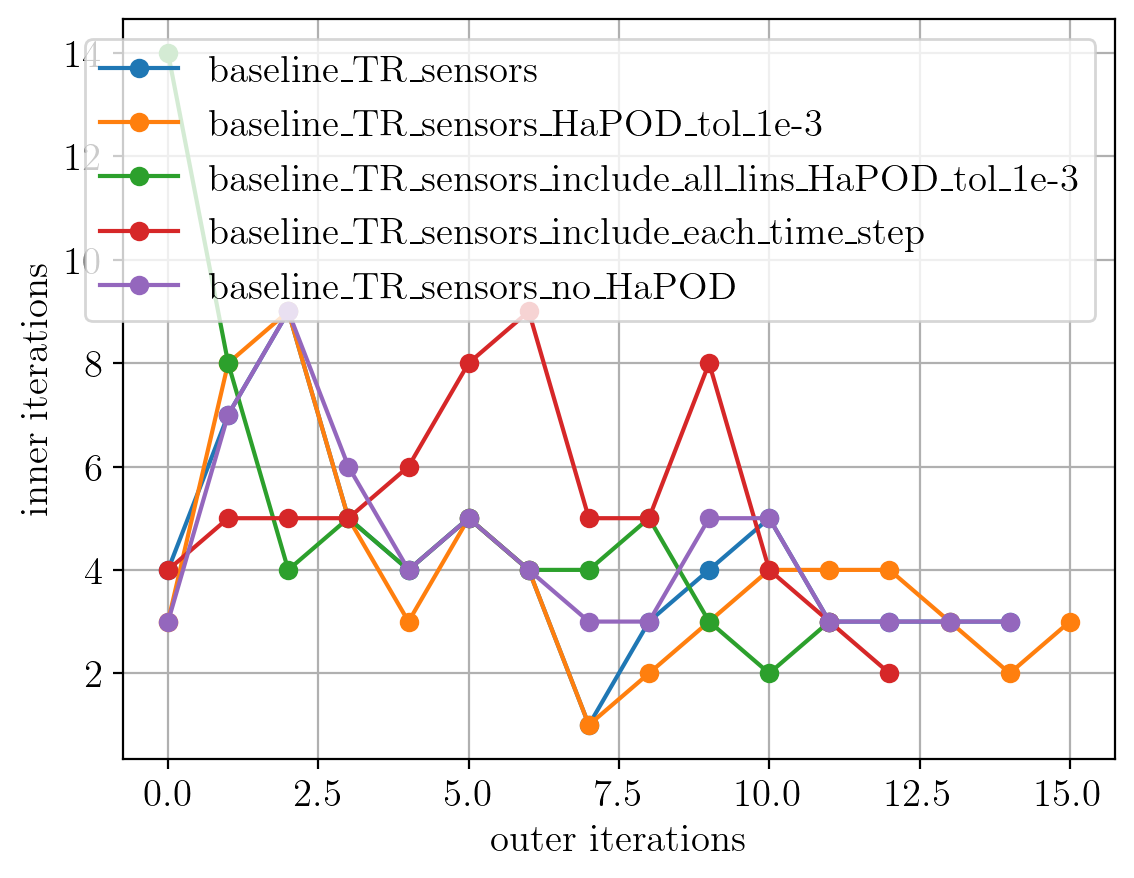

In [33]:
for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    num_inner_iterations = []
    inner_loop_statistics = experiment_data['inner_loop_statistics']
    for inner_loop_statistic in inner_loop_statistics:
        num_inner_iterations.append(len(inner_loop_statistic['J']))

    plt.plot(num_inner_iterations, marker='o', label=experiment_name)
        

plt.ylabel('inner iterations')
plt.xlabel('outer iterations')
plt.legend()
plt.grid()
            

In [ ]:
for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    plt.plot(experiment_data['abs_est_error_J_r'], marker='o', label=experiment_name)
    #plt.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        

#plt.ylabel('# inner iterations')


plt.ylabel('abs_est_error_J_r')
plt.xlabel('outer iterations')
plt.yscale('log')
plt.legend()
plt.grid()

In [ ]:
for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    plt.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        
#plt.axhline(0.10, color='black')
plt.axhline(0.15, color='black')

# beta_2 = optimizer_parameters['TR_30_5_10-5']['beta_2']
# plt.axhline(beta_2 * 0.10, color='black')
# plt.axhline(beta_2 *0.15, color='black')

plt.ylabel('rel_est_error_J_r')
plt.xlabel('outer iterations')
plt.yscale('log')
plt.legend()
plt.grid()
            